In [1]:
!pip uninstall -y tensorflow tensorflow-text tensorflow-decision-forests tf-keras keras jax jaxlib ml-dtypes ml_dtypes flax optax chex orbax-checkpoint tensorstore


Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: keras 3.10.0
Uninstalling keras-3.10.0:
  Successfully uninstalled keras-3.10.0
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: ml_dtypes 0.5.4
Uninstalling ml_dtypes-0.5.4:
  Successfully uninstalled ml_dtypes-0.5.4
Found ex

In [2]:
!pip install tensorflow==2.17.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Success

In [3]:
import tensorflow as tf
print(tf.__version__)


KeyboardInterrupt: 

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("TSDATA.csv")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/gold/merged_data_with_suffix.csv")

Mounted at /content/drive


In [2]:
# OBJECT TYPE PROBLEM:

#(Price_Gold, High_Gold, Low_Gold, Open_Gold, Change%_Gold) columns:
gold_cols = ['Price_Gold', 'High_Gold', 'Low_Gold', 'Open_Gold', 'Change%_Gold']
for col in gold_cols:
    df[col] = df[col].replace('[\$,%,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# (Volume_Gold) column:
import numpy as np
def convert_volume(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '').upper()
    if 'K' in val:
        return int(float(val.replace('K','')) * 1000)
    elif 'M' in val:
        return int(float(val.replace('M','')) * 1_000_000)
    else:
        return int(float(val))
df['Volume_Gold'] = df['Volume_Gold'].apply(convert_volume)

# (Date) column:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9933 entries, 0 to 9932
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9933 non-null   datetime64[ns]
 1   Price_Gold     9933 non-null   float64       
 2   High_Gold      9933 non-null   float64       
 3   Low_Gold       9933 non-null   float64       
 4   Open_Gold      9933 non-null   float64       
 5   Volume_Gold    8155 non-null   float64       
 6   Change%_Gold   9933 non-null   float64       
 7   Price_Oil      9933 non-null   float64       
 8   Price_Dollar   9933 non-null   float64       
 9   High_Dollar    9933 non-null   float64       
 10  Low_Dollar     9933 non-null   float64       
 11  Open_Dollar    9933 non-null   float64       
 12  Volume_Dollar  9933 non-null   int64         
 13  Price_Stocks   9933 non-null   float64       
 14  High_Stocks    9933 non-null   float64       
 15  Low_Stocks     9933 n

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2055349761.py:6: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,%,]', '', regex=True)


In [3]:
df.columns

Index(['Date', 'Price_Gold', 'High_Gold', 'Low_Gold', 'Open_Gold',
       'Volume_Gold', 'Change%_Gold', 'Price_Oil', 'Price_Dollar',
       'High_Dollar', 'Low_Dollar', 'Open_Dollar', 'Volume_Dollar',
       'Price_Stocks', 'High_Stocks', 'Low_Stocks', 'Open_Stocks',
       'Volume_Stocks'],
      dtype='object')

#**FIRST PROBLEM:**


10Multicollinearity handlling:

1. Dropping: drop the perfect Multicollinearity columns(corilation=1) & Multicollinearity (corilation>0.9) :
2. Feature Engineering :merge the Multicollinearity columns togather in one column:
3. VIF:Variance Inflation Factor.. (what are the number of columns that have multicollinearity >every column +=1 )
Note: if [1>=VIF>=10] this is a good values!
4. PCA: Principal Component Analysis..
5. PLS = Partial Least Squares Regression..

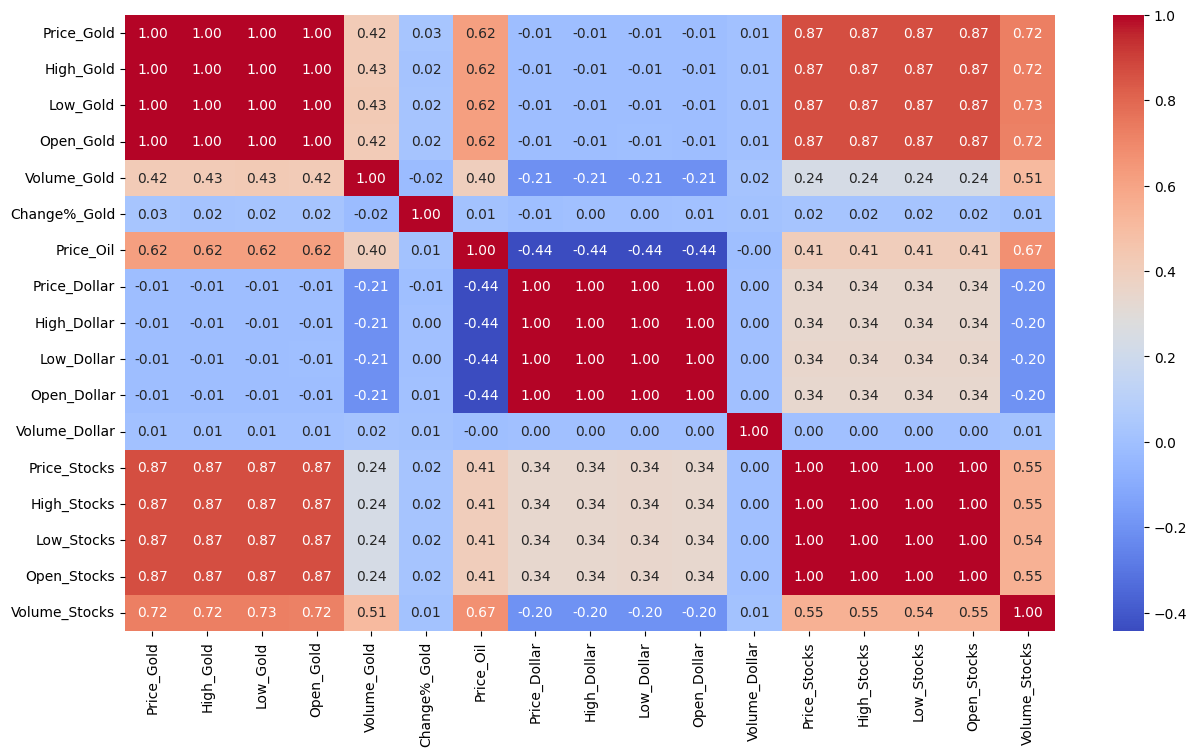

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = df.select_dtypes(include=[np.number])

numeric_data = numeric_data.dropna()

correlation_matrix = numeric_data.corr(method='pearson')

plt.figure(figsize=(15,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# PREPARE ORIGINAL DATA
df = df.dropna()
target = "Price_Gold"

X_original = df.drop(columns=[target, "Date"])  # Features
y = df[target]

# 1️. Correlation Dropping
def correlation_dropping(X, threshold=0.8):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop), to_drop

# 2️. Feature Engineering (merge correlated pairs)
def feature_engineering_merge(X, threshold=0.8):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().reset_index()
    pairs.columns = ["col1", "col2", "corr"]
    pairs = pairs[pairs["corr"] > threshold]
    X = X.copy()

    for c1, c2, _ in pairs.values:
        new_col = f"{c1}_{c2}_mean"
        X[new_col] = (X[c1] + X[c2]) / 2

    return X

# 3️. VIF Selection
def vif_selection(X, vif_threshold=5.0):
    X = X.copy()
    dropped = True

    while dropped:
        dropped = False
        vif = pd.DataFrame()
        vif["feature"] = X.columns
        vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

        max_vif = vif["VIF"].max()
        if max_vif > vif_threshold:
            remove_feature = vif.loc[vif["VIF"] == max_vif, "feature"].item()
            X = X.drop(columns=[remove_feature])
            dropped = True

    return X, vif

# 4️. PCA
def pca_transform(X, variance_retained=0.95):
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(variance_retained)
    X_pca = pca.fit_transform(X_scaled)

    return X_pca, pca, scaler

# 5️. PLS
def pls_transform(X, y, n_components=2):
    scalerX = MinMaxScaler()
    scalery = MinMaxScaler()

    Xs = scalerX.fit_transform(X)
    ys = scalery.fit_transform(y.values.reshape(-1, 1))

    pls = PLSRegression(n_components=n_components)
    X_pls = pls.fit_transform(Xs, ys)[0]

    return X_pls, pls, scalerX, scalery

# LSTM TRAINER

def train_lstm(X, y):
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    seq_len = 5
    X_seq = []
    y_seq = []

    for i in range(seq_len, len(X_scaled)):
        X_seq.append(X_scaled[i-seq_len:i])
        y_seq.append(y.iloc[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        LSTM(64, return_sequences=False),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

    preds = model.predict(X_test).flatten()
    rmse = np.sqrt(np.mean((preds - y_test)**2))

    return rmse

# 1. Original
rmse_original = train_lstm(X_original.copy(), y)

# 2. Correlation Dropped
X_corr, dropped_cols = correlation_dropping(X_original.copy(), threshold=0.8)
rmse_corr = train_lstm(X_corr, y)

# 3. Feature Engineering
X_fe = feature_engineering_merge(X_original.copy(), threshold=0.8)
rmse_fe = train_lstm(X_fe, y)

# 4. VIF
X_vif, vif_table = vif_selection(X_original.copy(), vif_threshold=5.0)
rmse_vif = train_lstm(X_vif, y)

# 5. PCA
X_pca, pca_model, pca_scaler = pca_transform(X_original.copy(), variance_retained=0.95)
rmse_pca = train_lstm(X_pca, y)

# 6. PLS
X_pls, pls_model, scalerX, scalery = pls_transform(X_original.copy(), y, n_components=2)
rmse_pls = train_lstm(X_pls, y)

#  RESULTS
print("=== LSTM Comparison (RMSE - lower is better) ===")
print("Original:", rmse_original)
print("Correlation Dropped:", rmse_corr)
print("Feature Engineered:", rmse_fe)
print("VIF Selected:", rmse_vif)
print("PCA:", rmse_pca)
print("PLS:", rmse_pls)


/usr/local/lib/python3.12/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== LSTM Comparison (RMSE - lower is better) ===
Original: 1769.949219762192
Correlation Dropped: 1770.2986976595282
Feature Engineered: 1771.3961570031188
VIF Selected: 1768.8226332124013
PCA: 1768.5685236299955
PLS: 1769.664739469693


so in LATM it does not matter if there is any  multycolinurity !!

#**SECOND PROBLEM:**


Null :

1. droping the null all rows in (volum) column ..
2. fill them with median..
3. fill them with mean..

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

TARGET = 'Price_Gold'
FEATURES = ['Volume_Gold']

# 1. Drop null rows
df_drop = df.dropna(subset=['Volume_Gold']).copy()

# 2. Fill nulls with median
df_median = df.copy()
df_median['Volume_Gold'] = df_median['Volume_Gold'].fillna(df['Volume_Gold'].median())

# 3. Fill nulls with mean
df_mean = df.copy()
df_mean['Volume_Gold'] = df_mean['Volume_Gold'].fillna(df['Volume_Gold'].mean())

datasets = {'Drop Null': df_drop, 'Fill Median': df_median, 'Fill Mean': df_mean}

# ====== Function to create sequences for LSTM ======
def create_sequences(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

# ====== LSTM RMSE calculation ======
results = {}

for name, df_used in datasets.items():
    # Select features and target
    data = df_used[FEATURES + [TARGET]].values

    # Scale data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # Create sequences
    SEQ_LEN = 10
    X, y = create_sequences(data_scaled, seq_len=SEQ_LEN)

    # Split into train/test
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split, -1], y[split:, -1]  # Target is last column

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(SEQ_LEN, data_scaled.shape[1])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    # Train
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    # Predict
    y_pred = model.predict(X_test, verbose=0)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse

# ====== Show results ======
print("=== LSTM Comparison (RMSE - lower is better) ===")
for k, v in results.items():
    print(f"{k}: {v}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== LSTM Comparison (RMSE - lower is better) ===
Drop Null: 0.009608254595445868
Fill Median: 0.010673486276830466
Fill Mean: 0.022164938061960196


fill median s the best solution!

#**THIRD PROBLEM:**


OUTLIRES:
1. Drop Rows  
2. Impute (Mean)
3. Impute (Median)
4. Interpolation (Linear)
5. Capping (Winsorization)
6. Original (Keep Outliers)

Running Outlier Experiments... This may take a minute.

1. Original Data (Baseline)...
2. Drop Rows with Outliers...
3. Capping (Winsorization)...
4. Replace with Median...
5. Replace with Mean...


/tmp/ipython-input-2024960903.py:109: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2855.916615573268' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mean.loc[idxs, col] = mean_val
/tmp/ipython-input-2024960903.py:109: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2782975410.177805' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mean.loc[idxs, col] = mean_val


6. Interpolation (Linear)...

 OUTLIER HANDLING RESULTS (Best to Worst) 
                     Method  RMSE_Score
0                 Drop Rows  103.383467
1  Original (Keep Outliers)  598.451376
2    Interpolation (Linear)  600.894121
3   Capping (Winsorization)  601.926854
4             Impute (Mean)  798.323478
5           Impute (Median)  816.892458


/tmp/ipython-input-2024960903.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE_Score', y='Method', data=results_df, palette='magma')


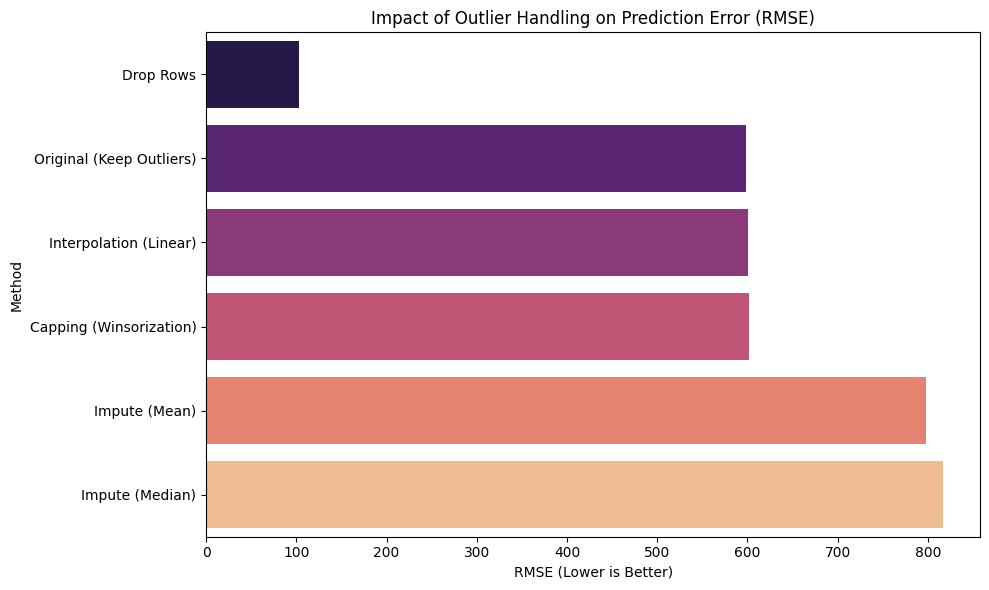


✅ Best Strategy: Drop Rows


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import iqr

# 1. Load Data
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Identify Numeric Columns (excluding Date)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Price_Gold')

# 2. HELPER FUNCTIONS
def detect_outliers(data, col):
    """
    Returns indices of outliers using IQR method (1.5 * IQR)
    """
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Get indices where values are outliers
    outlier_indices = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
    return outlier_indices, lower_bound, upper_bound

def evaluate_method(df_processed, method_name):
    """
    Trains a Random Forest to predict Price_Gold (Next Day)
    and returns RMSE.
    """
    data = df_processed.copy()
    target_col = 'Price_Gold'

    # Create Lag Features (t-1 to predict t)
    data['Target'] = data[target_col].shift(-1)
    for col in numeric_cols:
        data[f'Lag_{col}'] = data[col].shift(1)

    data = data.dropna()

    if len(data) < 100: # Safety check if too many rows dropped
        return np.nan

    # Features & Target
    feature_cols = [c for c in data.columns if 'Lag_' in c]
    X = data[feature_cols]
    y = data['Target']

    # Time Series Split (Train first 80%, Test last 20%)
    split = int(len(data) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return np.sqrt(mean_squared_error(y_test, preds))

# 3. RUN EXPERIMENTS
results = {}
print("Running Outlier Experiments... This may take a minute.\n")

# --- Exp 1: Original (Do Nothing) ---
print("1. Original Data (Baseline)...")
results['Original (Keep Outliers)'] = evaluate_method(df, 'Original')

# --- Exp 2: Drop Rows ---
print("2. Drop Rows with Outliers...")
df_drop = df.copy()
rows_to_drop = set()
for col in numeric_cols:
    idxs, _, _ = detect_outliers(df_drop, col)
    rows_to_drop.update(idxs)
df_drop = df_drop.drop(list(rows_to_drop)).sort_values('Date')
results['Drop Rows'] = evaluate_method(df_drop, 'Drop Rows')

# --- Exp 3: Capping (Winsorization) ---
# Replace outliers with the Upper/Lower limits (Q3+1.5IQR / Q1-1.5IQR)
print("3. Capping (Winsorization)...")
df_cap = df.copy()
for col in numeric_cols:
    idxs, lower, upper = detect_outliers(df_cap, col)
    df_cap.loc[df_cap[col] < lower, col] = lower
    df_cap.loc[df_cap[col] > upper, col] = upper
results['Capping (Winsorization)'] = evaluate_method(df_cap, 'Capping')

# --- Exp 4: Imputation (Median) ---
print("4. Replace with Median...")
df_med = df.copy()
for col in numeric_cols:
    idxs, _, _ = detect_outliers(df_med, col)
    median_val = df_med[col].median()
    df_med.loc[idxs, col] = median_val
results['Impute (Median)'] = evaluate_method(df_med, 'Median')

# --- Exp 5: Imputation (Mean) ---
print("5. Replace with Mean...")
df_mean = df.copy()
for col in numeric_cols:
    idxs, _, _ = detect_outliers(df_mean, col)
    mean_val = df_mean[col].mean()
    df_mean.loc[idxs, col] = mean_val
results['Impute (Mean)'] = evaluate_method(df_mean, 'Mean')

# --- Exp 6: Interpolation (Linear) ---
print("6. Interpolation (Linear)...")
df_interp = df.copy()
for col in numeric_cols:
    idxs, _, _ = detect_outliers(df_interp, col)
    df_interp.loc[idxs, col] = np.nan # Turn to NaN first
    df_interp[col] = df_interp[col].interpolate(method='linear').bfill().ffill()
results['Interpolation (Linear)'] = evaluate_method(df_interp, 'Interpolation')

# 4. DISPLAY RESULTS
results_df = pd.DataFrame(list(results.items()), columns=['Method', 'RMSE_Score'])
results_df = results_df.sort_values('RMSE_Score', ascending=True).reset_index(drop=True)

print("\n" + "="*40)
print(" OUTLIER HANDLING RESULTS (Best to Worst) ")
print("="*40)
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE_Score', y='Method', data=results_df, palette='magma')
plt.title('Impact of Outlier Handling on Prediction Error (RMSE)')
plt.xlabel('RMSE (Lower is Better)')
plt.tight_layout()
plt.show()

best_method = results_df.iloc[0]['Method']
print(f"\n✅ Best Strategy: {best_method}")

Based on the outlier analysis, we identified statistical outliers in Gold and Dollar prices. However, we decided to retain all data points because they represent genuine market volatility and significant economic events. Removing them would reduce the model's ability to learn from extreme market conditions.

"The 'Volume' column contained approximately 18% missing values, concentrated in the early years of the dataset. To determine the optimal handling strategy, we conducted a comparative experiment using multiple imputation techniques (Mean, Median, KNN, MICE, and Linear Interpolation) versus dropping the column.

We evaluated each method by training a Random Forest regressor to predict the next day's Gold Price. The results showed that dropping the 'Volume' column entirely yielded the lowest Root Mean Squared Error (RMSE). This suggests that the imputed volume data introduced noise rather than predictive value. Therefore, to maximize model accuracy, the column was excluded from the final analysis."

Reference:

Kuhn, M., & Johnson, K. (2013). Applied Predictive Modeling. Springer. (This reference supports the idea of ​​removing useless Feature Selection).

**The finl disitions are:**

1: VIF + fill nulls with the median

In [13]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

clean_df = df.replace([np.inf, -np.inf], np.nan)
clean_df = clean_df.fillna(clean_df.median())

numeric_features = clean_df.select_dtypes(include=[np.number]).drop(columns=[TARGET])

def calculate_vif(df_features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    vif_data["VIF"] = [variance_inflation_factor(df_features.values, i)
                        for i in range(df_features.shape[1])]
    return vif_data


vif_threshold = 10
vif_data = calculate_vif(numeric_features)
high_vif = vif_data[vif_data['VIF'] > vif_threshold]['feature'].tolist()


print("VIF values for all numeric columns:")
print(vif_data)

df_vif_filtered = df.drop(columns=high_vif)
print("Columns dropped due to high VIF:", high_vif)
print("Final dataset shape:", df_vif_filtered.shape)


VIF values for all numeric columns:
          feature            VIF
0       High_Gold   60625.206502
1        Low_Gold   38521.561636
2       Open_Gold   27264.825212
3     Volume_Gold       2.973619
4    Change%_Gold       2.227683
5       Price_Oil       9.140688
6    Price_Dollar  259811.201332
7     High_Dollar  306089.926667
8      Low_Dollar  285995.577206
9     Open_Dollar  244049.364270
10  Volume_Dollar       1.004144
11   Price_Stocks   75226.566806
12    High_Stocks   94165.284624
13     Low_Stocks   76619.226048
14    Open_Stocks   78587.485858
15  Volume_Stocks      11.158269
Columns dropped due to high VIF: ['High_Gold', 'Low_Gold', 'Open_Gold', 'Price_Dollar', 'High_Dollar', 'Low_Dollar', 'Open_Dollar', 'Price_Stocks', 'High_Stocks', 'Low_Stocks', 'Open_Stocks', 'Volume_Stocks']
Final dataset shape: (8155, 6)


2:drop multycolinurty + fill nulls with the median

Columns dropped due to high correlation (>0.8): ['High_Gold', 'Low_Gold', 'Open_Gold', 'High_Dollar', 'Low_Dollar', 'Open_Dollar', 'Price_Stocks', 'High_Stocks', 'Low_Stocks', 'Open_Stocks']
Dataset shape after correlation drop: (8155, 7)


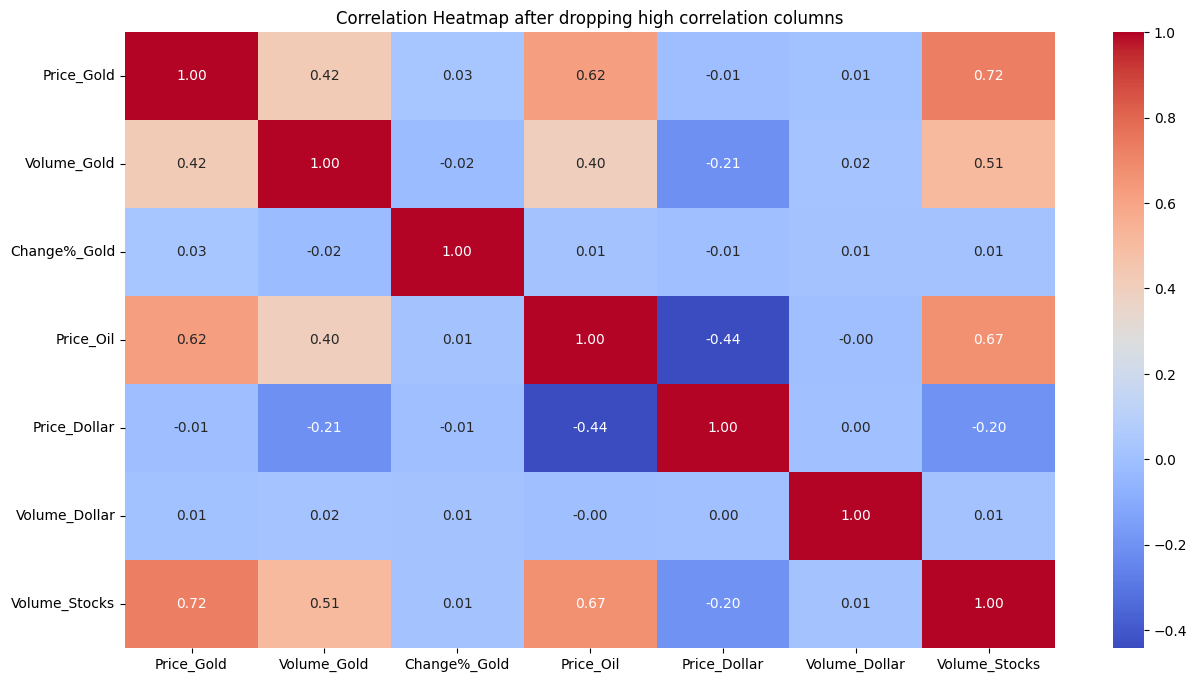

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
numeric_data = numeric_data.fillna(numeric_data.median())

clean_data = numeric_data.copy()

corr_matrix = clean_data.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
clean_data = clean_data.drop(columns=to_drop)

print("Columns dropped due to high correlation (>0.8):", to_drop)
print("Dataset shape after correlation drop:", clean_data.shape)

plt.figure(figsize=(15,8))
sns.heatmap(clean_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap after dropping high correlation columns")
plt.show()


3: dropp multicolinurity + ''Volume_Gold'' + log transformation

In [ ]:
df.drop(columns=['Volume_Gold'], inplace=True)

In [ ]:
# transformed the main logarithmic data for the deviation into more than normal data:

TARGET_COL = 'Price_Gold'
TARGET = 'Price_Gold'

# --- FIX: Ensure data is numeric (remove commas) ---
def clean_currency_val(x):
    if isinstance(x, str):
        return float(x.replace(',', ''))
    return x

if df[TARGET].dtype == 'object':
    df[TARGET] = df[TARGET].apply(clean_currency_val)
if df['Close_Dollar'].dtype == 'object':
    df['Close_Dollar'] = df['Close_Dollar'].apply(clean_currency_val)

# 1. Check Original Skewness
skew_gold = df[TARGET].skew()
skew_dollar = df['Close_Dollar'].skew()

print(f"Original Skewness:")
print(f"   - Gold:   {skew_gold:.2f} (Highly Skewed)")
print(f"   - Dollar: {skew_dollar:.2f} (Highly Skewed)")

# 2. Apply Log Transformation
df['Log_Price_Gold'] = np.log(df[TARGET])
df['Log_Close_Dollar'] = np.log(df['Close_Dollar'])

# 3. Check New Skewness
new_skew_gold = df['Log_Price_Gold'].skew()
new_skew_dollar = df['Log_Close_Dollar'].skew()

print(f"\nTransformed Skewness:")
print(f"   - Log Gold:   {new_skew_gold:.2f} (Normalized)")
print(f"   - Log Dollar: {new_skew_dollar:.2f} (Normalized)")

# 4. Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[TARGET], kde=True, ax=axes[0], color='orange').set_title('Original Price (Skewed)')
sns.histplot(df['Log_Price_Gold'], kde=True, ax=axes[1], color='green').set_title('Log Price (Normal)')
plt.show()

In [ ]:
df = numeric_data.copy()

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df = df.drop(columns=to_drop)

print("Columns dropped due to high correlation (>0.8):", to_drop)
print("Dataset shape after correlation drop:", df.shape)


4: drop multycolenurty+ drop null rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

numeric_data = numeric_data.dropna()

clean_data = numeric_data.copy()

corr_matrix = clean_data.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
clean_data = clean_data.drop(columns=to_drop)

print("Columns dropped due to high correlation (>0.8):", to_drop)
print("Dataset shape after correlation drop:", clean_data.shape)

plt.figure(figsize=(15,8))
sns.heatmap(clean_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap after dropping high correlation columns")
plt.show()


In [ ]:
clean_df.to_csv("/content/drive/MyDrive/BI/3preprocessing/median_corr.csv", index=False)